In [34]:
#импорт необходимых библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
#загрузка датасета
df = pd.read_csv('/train.csv')
df.duplicated().sum()
df = df.drop_duplicates()
df.head(3)
df.tail(3)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125
1459,1460,20,RL,75.0,9937,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2008,WD,Normal,147500


In [9]:
#отображение основной информации о датасете
df.info()
df.describe(include = "object")
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

,0
Id,0
MSSubClass,0
MSZoning,0
LotFrontage,259
LotArea,0
...,...
MoSold,0
YrSold,0
SaleType,0
SaleCondition,0


In [14]:
df['LotFrontage'] = df['LotFrontage'].fillna(df['LotFrontage'].mean()) # заполнение средним значением кажется наилучшим решением в столбце с длиной границы участка
df.head(8)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.000000,8450,Pave,Grvl,Reg,Lvl,AllPub,...,0,Gd,MnPrv,Shed,0,2,2008,WD,Normal,208500
1,2,20,RL,80.000000,9600,Pave,Grvl,Reg,Lvl,AllPub,...,0,Gd,MnPrv,Shed,0,5,2007,WD,Normal,181500
2,3,60,RL,68.000000,11250,Pave,Grvl,IR1,Lvl,AllPub,...,0,Gd,MnPrv,Shed,0,9,2008,WD,Normal,223500
3,4,70,RL,60.000000,9550,Pave,Grvl,IR1,Lvl,AllPub,...,0,Gd,MnPrv,Shed,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.000000,14260,Pave,Grvl,IR1,Lvl,AllPub,...,0,Gd,MnPrv,Shed,0,12,2008,WD,Normal,250000
5,6,50,RL,85.000000,14115,Pave,Grvl,IR1,Lvl,AllPub,...,0,Gd,MnPrv,Shed,700,10,2009,WD,Normal,143000
6,7,20,RL,75.000000,10084,Pave,Grvl,Reg,Lvl,AllPub,...,0,Gd,MnPrv,Shed,0,8,2007,WD,Normal,307000
7,8,60,RL,70.049958,10382,Pave,Grvl,IR1,Lvl,AllPub,...,0,Gd,MnPrv,Shed,350,11,2009,WD,Normal,200000


In [17]:
#посчёт min, max, median, mean, mode
print(df['LotArea'].mean())
print(df['LotArea'].min())
print(df['LotArea'].max())
print(df['LotArea'].median())
print(df['LotArea'].mode())
print(df['LotFrontage'].mean())
print(df['LotFrontage'].min())
print(df['LotFrontage'].max())
print(df['LotFrontage'].median())
print(df['LotFrontage'].mode())

10516.828082191782
1300
215245
9478.5
0    7200
Name: LotArea, dtype: int64
70.04995836802664
21.0
313.0
70.04995836802665
0    70.049958
Name: LotFrontage, dtype: float64


In [18]:
# подсчёт quantile
print(df['LotArea'].quantile(0.25))
print(df['LotArea'].quantile(0.5))
print(df['LotArea'].quantile(0.75))

print(df['LotFrontage'].quantile(0.25))
print(df['LotFrontage'].quantile(0.5))
print(df['LotFrontage'].quantile(0.75))

7553.5
9478.5
11601.5
60.0
70.04995836802665
79.0


In [19]:
#кодирование категорий
df_encoded = pd.get_dummies(df, columns = ['Alley'], prefix = 'Alley')
print(df_encoded)

        Id  MSSubClass MSZoning  LotFrontage  LotArea Street LotShape  \
0        1          60       RL         65.0     8450   Pave      Reg   
1        2          20       RL         80.0     9600   Pave      Reg   
2        3          60       RL         68.0    11250   Pave      IR1   
3        4          70       RL         60.0     9550   Pave      IR1   
4        5          60       RL         84.0    14260   Pave      IR1   
...    ...         ...      ...          ...      ...    ...      ...   
1455  1456          60       RL         62.0     7917   Pave      Reg   
1456  1457          20       RL         85.0    13175   Pave      Reg   
1457  1458          70       RL         66.0     9042   Pave      Reg   
1458  1459          20       RL         68.0     9717   Pave      Reg   
1459  1460          20       RL         75.0     9937   Pave      Reg   

     LandContour Utilities LotConfig  ...  Fence MiscFeature MiscVal MoSold  \
0            Lvl    AllPub    Inside  ...  M

In [28]:
#создание новых фичей
df['HasAllUtils'] = (df['Utilities'] == 'AllPub').astype(int)  #Все ли коммуникации?
df['IsCulDeSac'] = (df['LotConfig'] == 'CulDSac').astype(int) #Тип участка

/tmp/ipykernel_574/2097894221.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='MSZoning', y='SalePrice', data=df, palette='Set3')


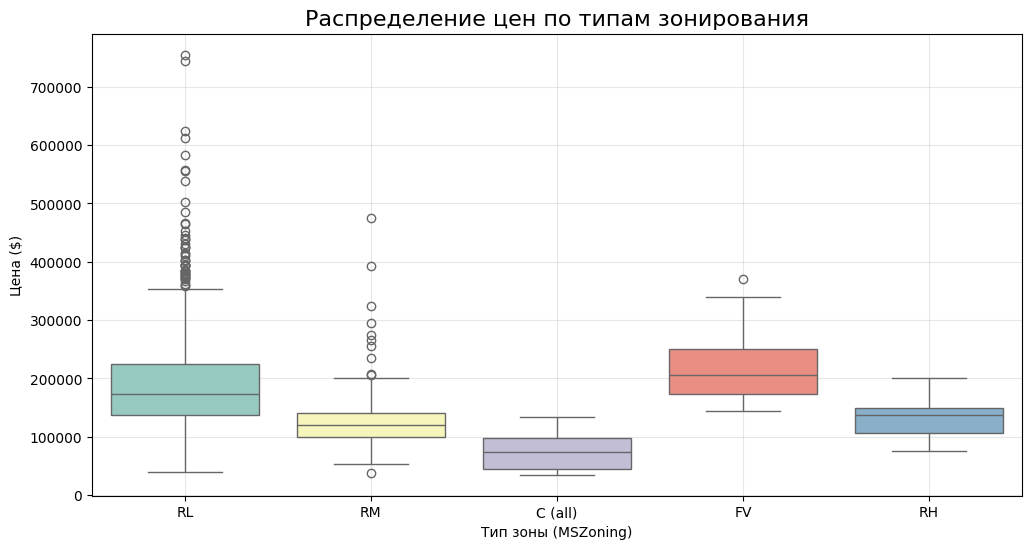

In [29]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='MSZoning', y='SalePrice', data=df, palette='Set3')
plt.title('Распределение цен по типам зонирования', fontsize=16)
plt.xlabel('Тип зоны (MSZoning)')
plt.ylabel('Цена ($)')
plt.grid(True, alpha=0.3)
plt.show()

In [32]:
fig1 = px.box(df, x='MSZoning', y='SalePrice', color='MSZoning',
              title='Распределение цен по зонам',
              points='all')
fig1.show()

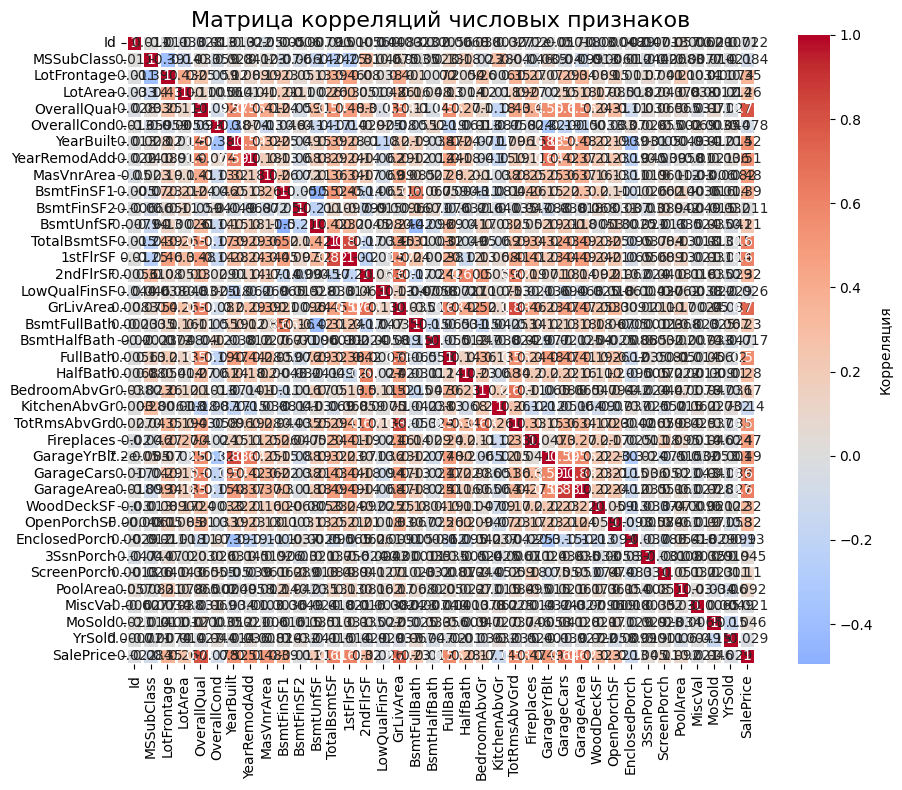

In [35]:
plt.figure(figsize=(10, 8))
numeric_cols = df.select_dtypes(include=[np.number]).columns
correlation = df[numeric_cols].corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={'label': 'Корреляция'})
plt.title('Матрица корреляций числовых признаков', fontsize=16)
plt.tight_layout()
plt.show()

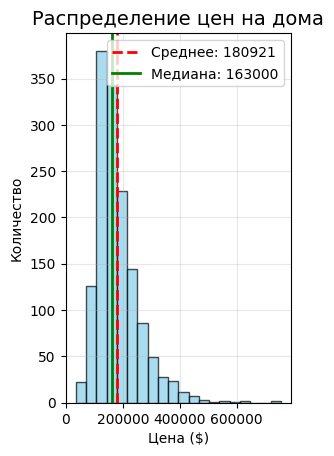

In [36]:
plt.subplot(1, 2, 1)
plt.hist(df['SalePrice'], bins=20, color='skyblue', edgecolor='black', alpha=0.7)
plt.axvline(df['SalePrice'].mean(), color='red', linestyle='--', linewidth=2, label=f'Среднее: {df["SalePrice"].mean():.0f}')
plt.axvline(df['SalePrice'].median(), color='green', linestyle='-', linewidth=2, label=f'Медиана: {df["SalePrice"].median():.0f}')
plt.title('Распределение цен на дома', fontsize=14)
plt.xlabel('Цена ($)')
plt.ylabel('Количество')
plt.legend()
plt.grid(True, alpha=0.3)

In [37]:
#много выбросов в столбце LotArea
#RL - элитный район(по стоимости домов)
#пропуски в LotFrontage нужно заполнять медианой по району
#почти все дома имеют коммуникации(utilities)
#в колонке Street 100% Pave
#в колонке Alley слишком много пропусков NaN (94%)
#колонка MSZoning сильно перекошена


In [ ]:
#качество района важнее размера дома
#дома в тупике стоят дороже
#комбинация признаков важнее каждого по отдельности

In [ ]:
#дальше можно было бы обучить модель линейной регрессии

In [ ]:
#у AI помощников спрашивал про работу с библиотеками для визуализации данных